In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter
import json
from sklearn.metrics import root_mean_squared_error as rmse
from rdkit import Chem

In [2]:
data = pd.read_json('your_path_to_free_solv/database.json') #replace with your path

In [3]:
mobleys = ['36119','186894','242480','296847','337666','468867','1017962','1034539','1662128','1770205','2023925','2197088','2341732','2518989','3047364','3169935','3201701','4013838','7455579','7754849','8492526','9897248'] #selected molecules

In [4]:
functional_groups = []
for mol in mobleys:
    for i in data[f'mobley_{mol}']['groups']:
        functional_groups.append(i)
functional_groups = np.array(functional_groups)

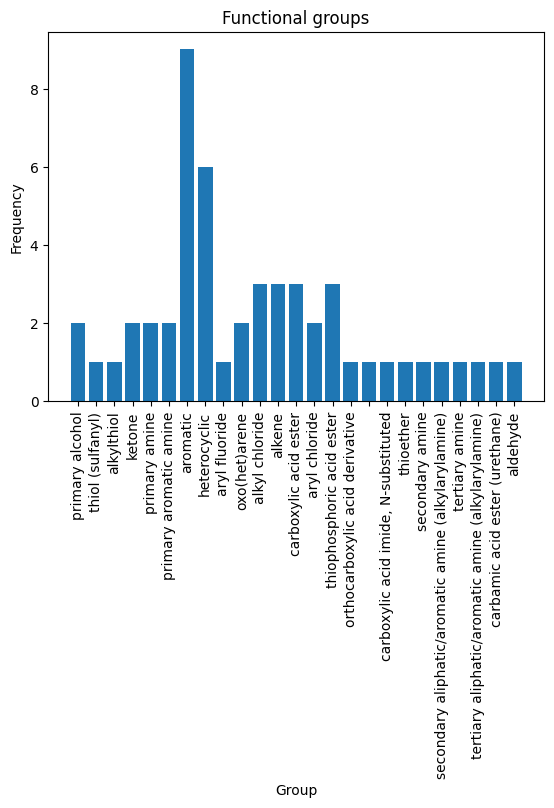

In [5]:
# histogram functional groups frequency
counts = Counter(functional_groups)
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values)
plt.xlabel('Group')
plt.ylabel('Frequency')
plt.title('Functional groups')

# Rotate x-axis labels if needed
plt.xticks(rotation=90)

plt.show()

In [6]:
# There is a molecule without functional groups
for mol in mobleys:
    for i in data[f'mobley_{mol}']['groups']:
        if i == '':
            print(mol)

2197088


In [7]:
mobleys_new = [i for i in mobleys if i!= '2197088'] # eliminate the molecule with no functional groups

In [8]:
# Dictionary of SMARTS
functional_group_smarts = {
    'aldehyde': '[CX3H1](=O)[#6]',  # e.g. -CHO
    'alkene': 'C=C',                # Simple alkene
    'alkyl chloride': '[CX4][Cl]',  # Aliphatic C–Cl
    'alkylthiol': '[CX4][SH]',      # Aliphatic thiol
    'aromatic': 'a',                # Any aromatic atom
    'aryl chloride': 'c[Cl]',       # Aromatic C–Cl
    'aryl fluoride': 'c[F]',        # Aromatic C–F
    'carbamic acid ester (urethane)': 'O=C(OC)N',  # Simple urethane motif
    'carboxylic acid ester': 'C(=O)O[CX4]',        # R–COOR'
    'carboxylic acid imide, N-substituted': 'C(=O)N(C)C(=O)',  # e.g., phthalimide
    'heterocyclic': '[a;!#6]',      # Aromatic non-carbon atom
    'ketone': '[#6][CX3](=O)[#6]',  # R–C(=O)–R
    'orthocarboxylic acid derivative': '[C;X4]([O][#6])([O][#6])([O][#6])',
    'oxo(het)arene': '[c,n,o,s]=O',  # Oxidized heteroarene (generalized)
    'primary alcohol': '[CX4][CH2][OH]',  # R–CH2–OH
    'primary amine': '[NX3;H2,H1;!$(NC=O)]', 
    'primary aromatic amine': '[NX3;H2][c]',  # Ar–NH2
    'secondary aliphatic/aromatic amine (alkylarylamine)': '[NX3;H1]([CX4])[c]',  # R–NH–Ar
    'secondary amine': '[NX3;H1][CX4;!$(C=O)]',  # R2NH
    'tertiary aliphatic/aromatic amine (alkylarylamine)': '[NX3]([CX4])[c]',  # R–N(R')–Ar
    'tertiary amine': '[NX3]([CX4])[CX4]',  # R3N
    'thioether': '[#16][CX4]',  # R–S–R'
    'thiol (sulfanyl)': '[CX4][SH]',  # R–SH
    'thiophosphoric acid ester': 'P(=S)(OC)(OC)'  # Simplified model
}


In [9]:
unique_group = [i for i in np.unique(functional_groups) if i!='']
unique_group = np.array(unique_group)

In [18]:
# Sum of charges on each group
chg_group_am1 = [[] for i in unique_group]
chg_group_dft = [[] for i in unique_group]
chg_group_per = [[] for i in unique_group]
for mob in mobleys_new:
    mol = Chem.SDMolSupplier(f'../ahfe_calculations/molecules/sdf/mobley_{mob}.sdf')[0]
    #load computed charges
    chgs_dft = np.load(f'../ahfe_calculations/esp_charges/mobley_{mob}.npy')
    chgs_am1 = np.load(f'../ahfe_calculations/am1bcc_charges/mobley_{mob}.npy')
    chgs_per = np.load(f'../ahfe_calculations/bp_charges/mobley_{mob}.npy')
    mol_groups = data[f'mobley_{mob}']['groups']
    for grp in mol_groups:
        #where I will add in the lists
        idx = np.where(unique_group == grp)[0][0]
        smart = functional_group_smarts[grp]
        patt = Chem.MolFromSmarts(smart)
        matches = mol.GetSubstructMatches(patt)
        sum_dft = 0
        sum_am1 = 0
        sum_per = 0
        # getting the sum of the charges on each group
        if len(matches) > 0:
            for i in matches[0]:
                sum_dft += chgs_dft[i]
                sum_am1 += chgs_am1[i]
                sum_per += chgs_per[i]
            chg_group_am1[idx].append(sum_am1)
            chg_group_dft[idx].append(sum_dft)
            chg_group_per[idx].append(sum_per)
        else:
            print('No matches for molecule: ',mob,' group', grp)

No matches for molecule:  2023925  group orthocarboxylic acid derivative
No matches for molecule:  2518989  group heterocyclic
No matches for molecule:  3201701  group carbamic acid ester (urethane)
No matches for molecule:  9897248  group primary alcohol


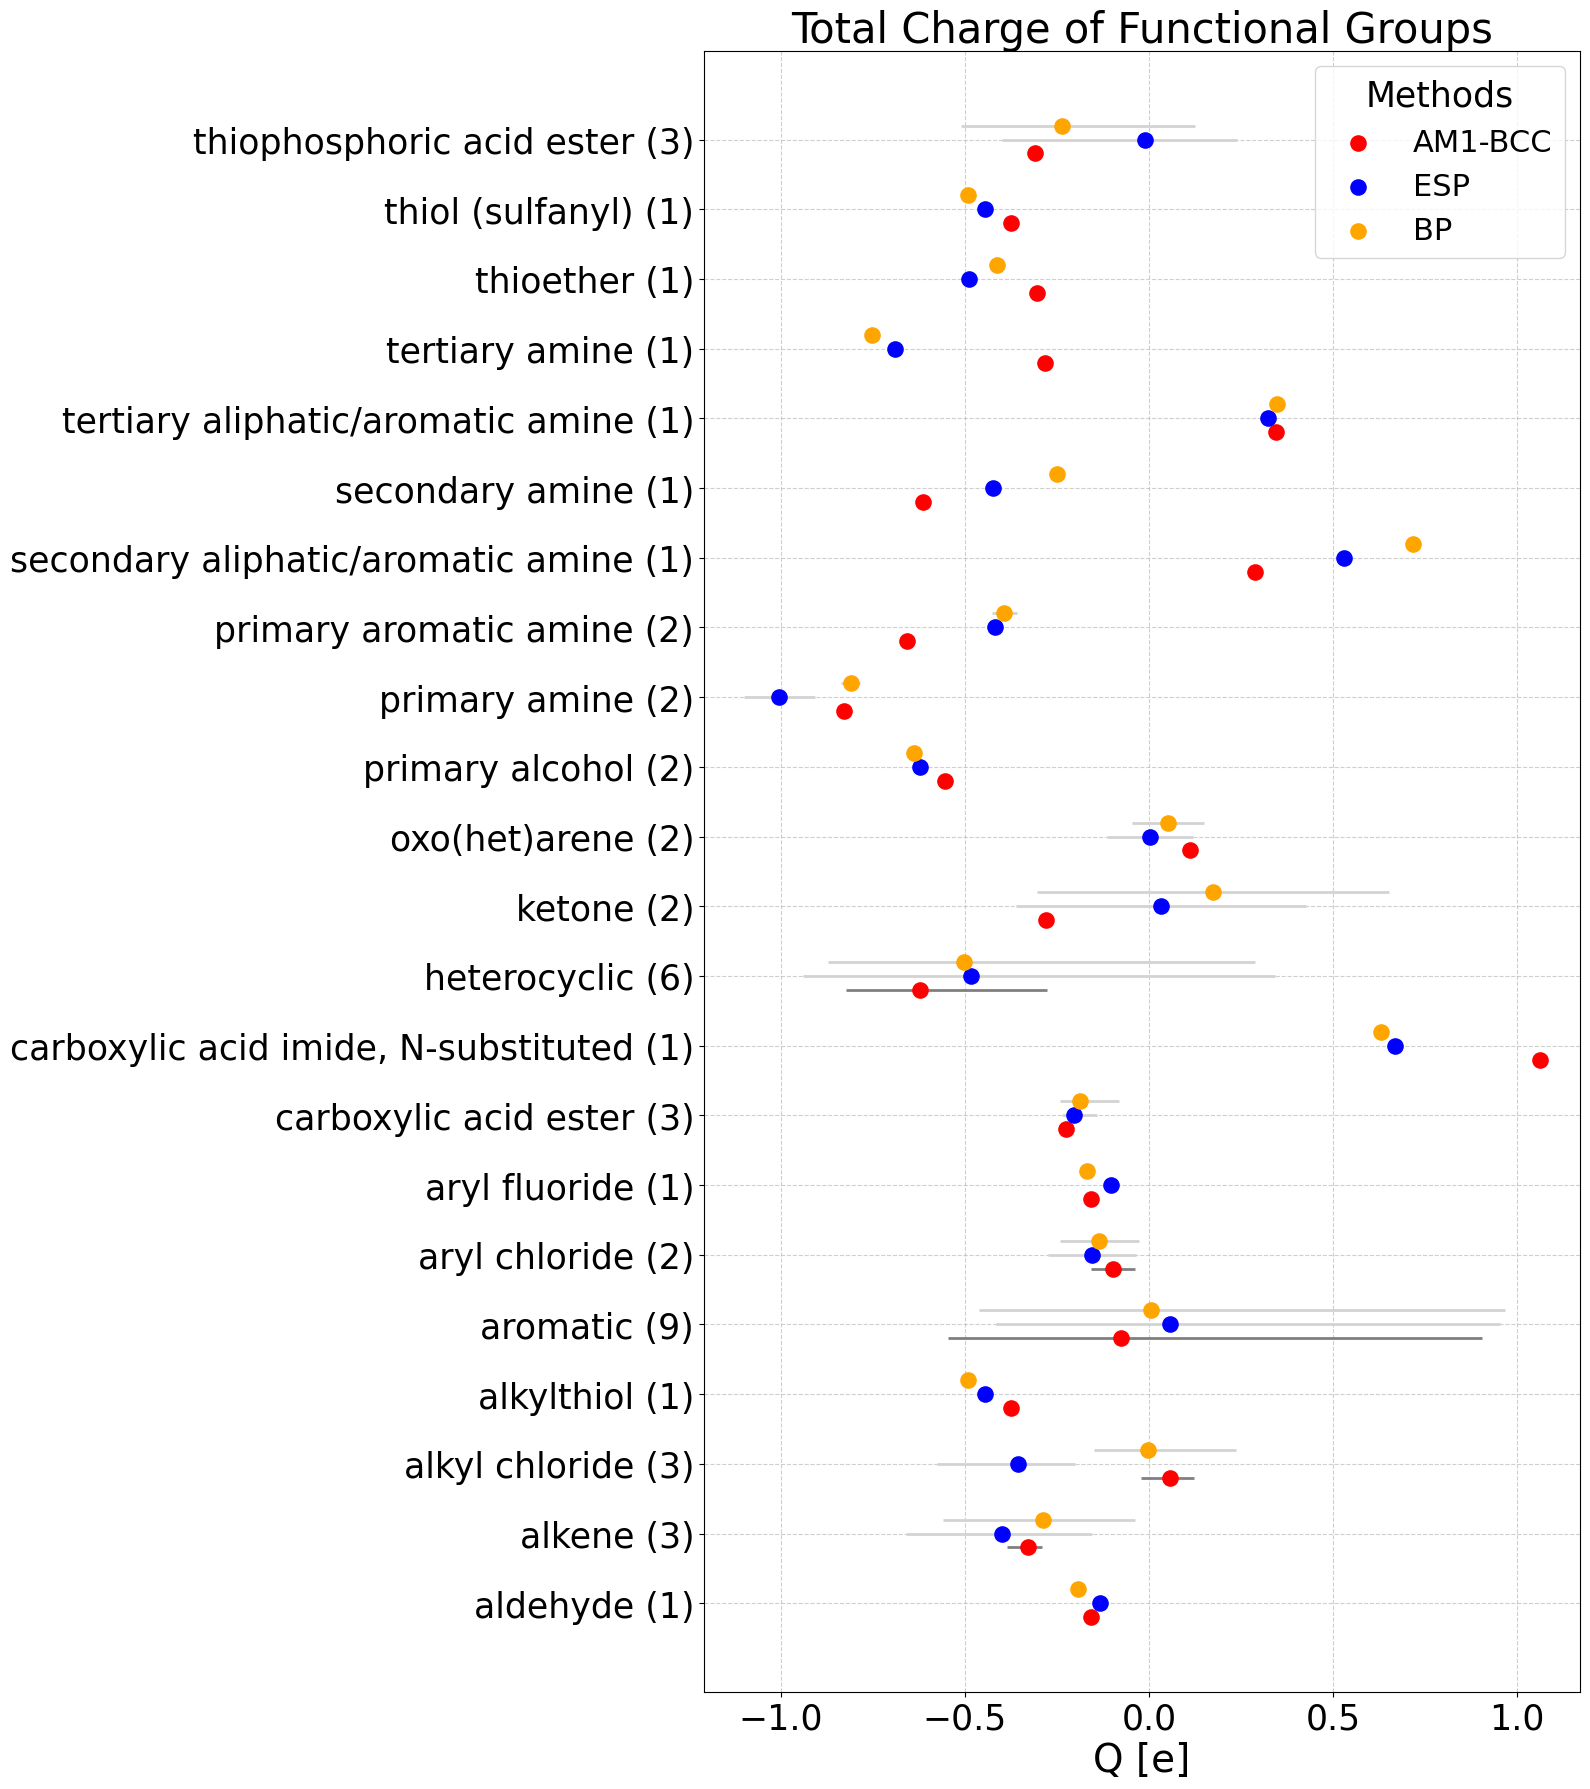

In [21]:
# Plot
unique = unique_group
method1 = chg_group_am1
method2 = chg_group_dft
method3 = chg_group_per
# Filter out positions where data is missing
valid_indices = [
    i for i in range(len(unique))
    if method1[i] and method2[i]  # both lists non-empty
]

# Filtered data
unique_filtered = [unique[i] for i in valid_indices]
method1_filtered = [method1[i] for i in valid_indices]
method2_filtered = [method2[i] for i in valid_indices]
method3_filtered = [method3[i] for i in valid_indices]
values = [counts.get(label, 0) for label in unique_filtered]
# Compute stats
mins1 = [np.min(d) for d in method1_filtered]
maxs1 = [np.max(d) for d in method1_filtered]
means1 = [np.mean(d) for d in method1_filtered]

mins2 = [np.min(d) for d in method2_filtered]
maxs2 = [np.max(d) for d in method2_filtered]
means2 = [np.mean(d) for d in method2_filtered]

mins3 = [np.min(d) for d in method3_filtered]
maxs3 = [np.max(d) for d in method3_filtered]
means3 = [np.mean(d) for d in method3_filtered]

x = np.arange(len(unique_filtered))
offset = 0.20

fig, ax = plt.subplots(figsize=(16, 18))

# Plot Method 1 (horizontal)
ax.hlines(x - offset, mins1, maxs1, color='gray', linewidth=2)
ax.scatter(means1, x - offset, color='red', label='AM1-BCC', zorder=3,s=120)

# Plot Method 2 (horizontal)
ax.hlines(x, mins2, maxs2, color='lightgray', linewidth=2)
ax.scatter(means2, x, color='blue', label='ESP', zorder=3,s=120)

# Plot Method 3 (horizontal)
ax.hlines(x + offset, mins3, maxs3, color='lightgray', linewidth=2)
ax.scatter(means3, x + offset, color='orange', label='BP', zorder=3,s=120)

# Label modifications for shorter label
unique_filtered[15] = 'secondary aliphatic/aromatic amine'
unique_filtered[17] = 'tertiary aliphatic/aromatic amine'

# Combine label + value in parentheses
labels_with_values = [f"{name} ({val})" for name, val in zip(unique_filtered, values)]

# Axes setup
ax.set_yticks(x)
ax.set_yticklabels(labels_with_values, fontsize=25)
plt.xticks(fontsize=25)
ax.set_xlabel('Q [e]', fontsize=28)
#ax.set_ylabel('Functional group', fontsize=14)
ax.set_title('Total Charge of Functional Groups', fontsize=30)
ax.legend(title="Methods",
    fontsize=22,          # size of the legend labels ("BP", "ESP", "RESP")
    title_fontsize=25,    # size of the "Methods" title
    loc="upper right",    # optional: move it if it overlaps the plot
    frameon=True           # optional: give it a visible frame
    )
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('func_groups_chgs.png')
plt.show()